<a href="https://colab.research.google.com/github/irghan17/Python-Statistical-Modeling/blob/main/Tugas_3__Teknik_Pengolahan_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tugas Teknik Pengolahan Data 3
**Irghan Santiz Ruqi A**

1. Menyusun Grafik Moving Average
2. Menyusun Boxplot
3. Menyusun Duration Curve dengan persentil 80%

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/00_/Semester 1/Teknik Pengelolaan Data/Collabs/ClimateEngine_2024_2026.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Temp
0,2024-07-01,29.20
1,2024-07-02,29.10
2,2024-07-03,30.83
3,2024-07-04,29.91
4,2024-07-05,29.02


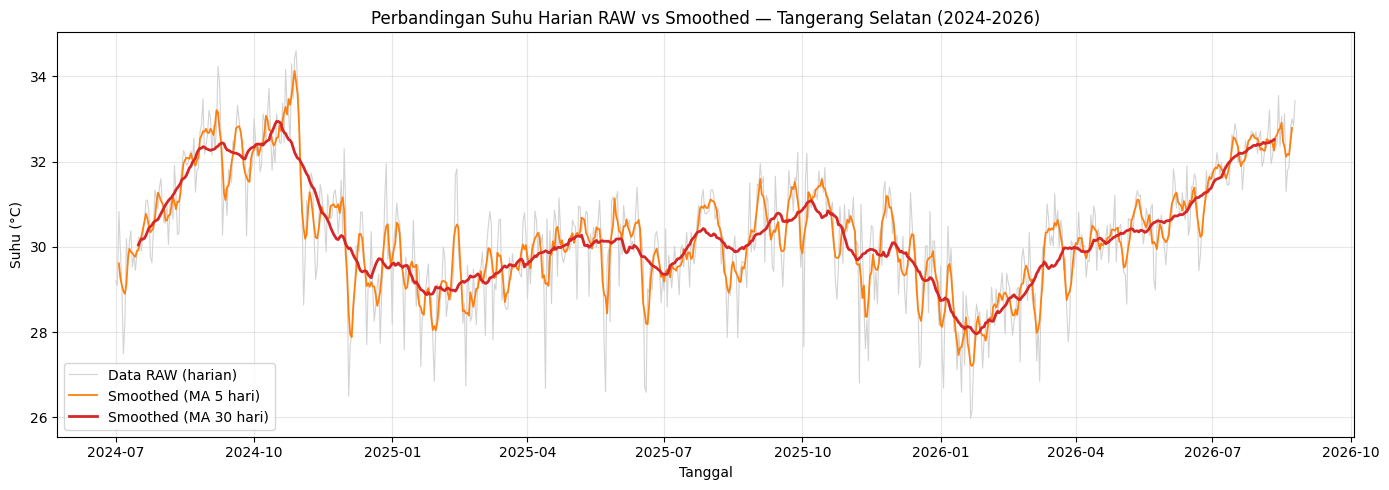

In [ ]:
# Hitung moving average 5 hari dan 30 hari
df['MA5']  = df['Temp'].rolling(window=5,  center=True).mean()
df['MA30'] = df['Temp'].rolling(window=30, center=True).mean()

plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Temp'], color='lightgray', linewidth=0.8, label='Data RAW (harian)')
plt.plot(df['Date'], df['MA5'],  color='tab:orange', linewidth=1.3, label='Smoothed (MA 5 hari)')
plt.plot(df['Date'], df['MA30'], color='tab:red', linewidth=2.0, label='Smoothed (MA 30 hari)')

plt.title('Perbandingan Suhu Harian RAW vs Smoothed — Tangerang Selatan (2024-2026)')
plt.xlabel('Tanggal')
plt.ylabel('Suhu (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('grafik_raw_smooth.png', dpi=200)
plt.show()

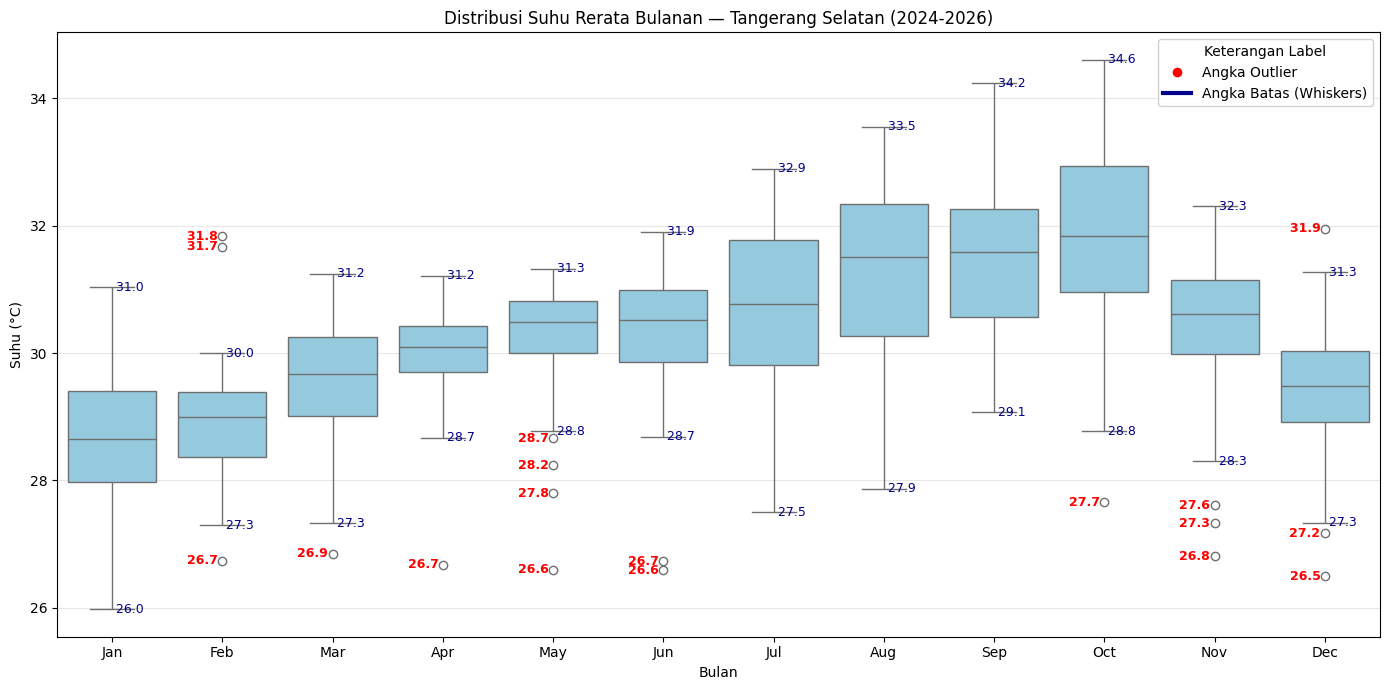

In [ ]:
from matplotlib.lines import Line2D

df['Bulan'] = df['Date'].dt.month
df['NamaBulan'] = df['Date'].dt.strftime('%b')

urutan_bulan = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14,7))

# Simpan objek plot ke dalam variabel 'ax'
ax = sns.boxplot(data=df, x='NamaBulan', y='Temp', order=urutan_bulan, color='skyblue')

# --- LOGIKA UNTUK MENAMBAHKAN LABEL BATAS & OUTLIER ---
for i, month in enumerate(urutan_bulan):
    # Ambil data suhu khusus untuk bulan ini
    month_data = df[df['NamaBulan'] == month]['Temp'].dropna()

    if month_data.empty:
        continue

    # Hitung Q1, Q3, dan IQR
    q1 = month_data.quantile(0.25)
    q3 = month_data.quantile(0.75)
    iqr = q3 - q1

    # Hitung batas teoretis
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Cari nilai aktual untuk batas bawah dan atas (whiskers)
    actual_lower_whisker = month_data[month_data >= lower_bound].min()
    actual_upper_whisker = month_data[month_data <= upper_bound].max()

    # Cari data outlier
    outliers = month_data[(month_data < lower_bound) | (month_data > upper_bound)]

    # 1. Tambahkan label untuk Batas Atas & Batas Bawah (Warna Biru Gelap)
    ax.text(i, actual_upper_whisker, f' {actual_upper_whisker:.1f}',
            ha='left', va='center', color='darkblue', fontsize=9)
    ax.text(i, actual_lower_whisker, f' {actual_lower_whisker:.1f}',
            ha='left', va='center', color='darkblue', fontsize=9)

    # 2. Tambahkan label untuk setiap Outlier (Warna Merah)
    for out_val in outliers.unique():
        ax.text(i, out_val, f'{out_val:.1f} ',
                ha='right', va='center', color='red', fontsize=9, fontweight='bold')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Angka Outlier'),
    Line2D([0], [0], color='darkblue', lw=3, label='Angka Batas (Whiskers)')
]

ax.legend(handles=legend_elements, loc='upper right', title='Keterangan Label', framealpha=0.9)

plt.title('Distribusi Suhu Rerata Bulanan — Tangerang Selatan (2024-2026)')
plt.xlabel('Bulan')
plt.ylabel('Suhu (°C)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_suhu_bulanan_berlabel_legenda.png', dpi=200)
plt.show()

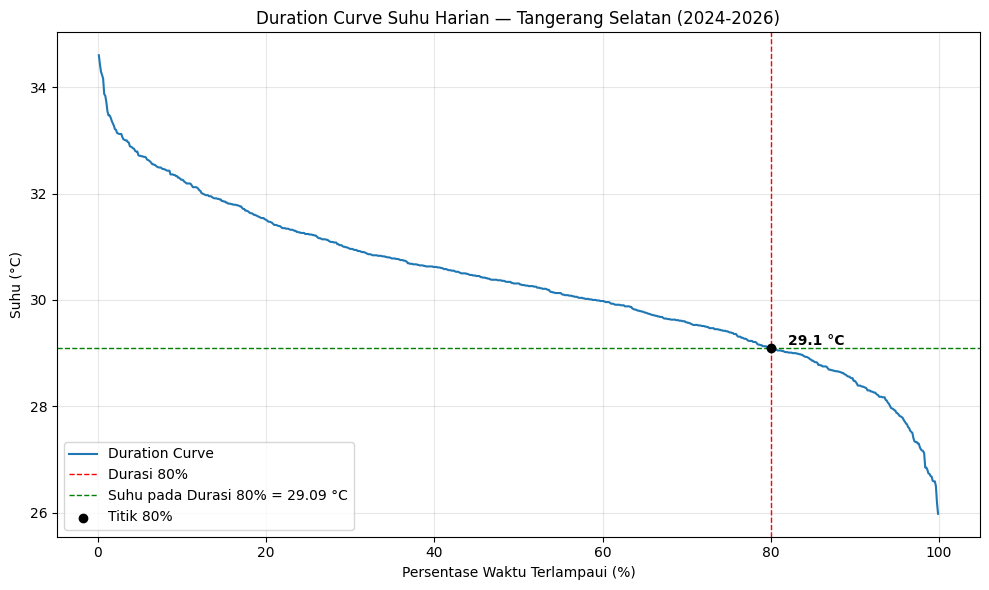

Suhu yang terlampaui 80% waktu: 29.09 °C


In [ ]:
suhu_terurut = np.sort(df['Temp'].values)[::-1]  # urut besar ke kecil
n = len(suhu_terurut)

persen_durasi = (np.arange(1, n + 1) / (n + 1)) * 100

suhu_durasi_80 = np.interp(80, persen_durasi, suhu_terurut)

plt.figure(figsize=(10,6))
plt.plot(persen_durasi, suhu_terurut, color='tab:blue', linewidth=1.5, label='Duration Curve')

# Garis vertikal dan horizontal
plt.axvline(80, color='red', linestyle='--', linewidth=1, label='Durasi 80%')
plt.axhline(suhu_durasi_80, color='green', linestyle='--', linewidth=1, label=f'Suhu pada Durasi 80% = {suhu_durasi_80:.2f} °C')

# Titik perpotongan (sesuai lingkaran merah pada gambar referensi)
plt.scatter([80], [suhu_durasi_80], color='black', zorder=5, label='Titik 80%')

# Tambahkan label teks tepat di sebelah titik perpotongan
plt.text(82, suhu_durasi_80, f'{suhu_durasi_80:.1f} °C',
         verticalalignment='bottom', horizontalalignment='left',
         color='black', fontweight='bold', fontsize=10)

plt.title('Duration Curve Suhu Harian — Tangerang Selatan (2024-2026)')
plt.xlabel('Persentase Waktu Terlampaui (%)')
plt.ylabel('Suhu (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('duration_curve_diperbaiki.png', dpi=200)
plt.show()

print(f'Suhu yang terlampaui 80% waktu: {suhu_durasi_80:.2f} °C')